# Phan tich PM2.5 Ha Noi

Notebook tao 7 bang output va 7 bieu do de tra loi cac cau hoi phan tich, du doan va phan cum PM2.5.

PM2.5 là bụi mịn có đường kính nhỏ hơn hoặc bằng 2.5 micromet.
- PM = Particulate Matter = bụi/ hạt vật chất lơ lửng trong không khí
- 2.5 = kích thước hạt bụi nhỏ hơn hoặc bằng 2.5 micromet

Nếu PM2.5 trung bình ngày > 50 µg/m3
→ ngày đó được xem là vượt ngưỡng
→ chất lượng không khí đáng chú ý, có nguy cơ ảnh hưởng sức khỏe

In [15]:
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
import os
from pathlib import Path

# Tim file data trong cwd va cac thu muc cha (toi da 6 cap)
CURRENT_DIR = Path.cwd()
p = CURRENT_DIR
BASE_DIR = None
for _ in range(6):
    candidate = p / "data" / "hanoi_aqi_ml_ready_fixed.csv"
    if candidate.exists():
        BASE_DIR = p
        break
    if p.parent == p:
        break
    p = p.parent

if BASE_DIR is None:
    # Try common fallback: repository root relative to this notebook file location
    nb_path = Path(__file__).resolve() if '__file__' in globals() else None
    if nb_path is not None:
        candidate = nb_path.parent / '..' / 'data' / 'hanoi_aqi_ml_ready_fixed.csv'
        candidate = candidate.resolve()
        if candidate.exists():
            BASE_DIR = candidate.parent.parent

if BASE_DIR is None:
    raise FileNotFoundError("Khong tim thay file data/hanoi_aqi_ml_ready_fixed.csv")

DATA_PATH = BASE_DIR / "data" / "hanoi_aqi_ml_ready_fixed.csv"
# Cau hinh mac dinh (co the sua de phu hop voi pham vi phan tich)
NGAY_BAT_DAU = "2024-02-14"
NGAY_KET_THUC = "2026-01-26"
NGUONG_PM25 = 50
OUTPUT_DIR = BASE_DIR / "output"
CHART_DIR = BASE_DIR / "output" / "bieu_do"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_PATH:", DATA_PATH)

BASE_DIR: d:\ky3D\pm25_hanoi_project
DATA_PATH: d:\ky3D\pm25_hanoi_project\data\hanoi_aqi_ml_ready_fixed.csv


In [17]:
# ============================================================
df = pd.read_csv(DATA_PATH)

df["datetime"] = pd.to_datetime(df["datetime"])

df = df[
    (df["datetime"] >= pd.Timestamp(NGAY_BAT_DAU)) &
    (df["datetime"] <= pd.Timestamp(NGAY_KET_THUC + " 23:59:59"))
].copy()

df = df.dropna(subset=["pm25"])

df["ngay"] = df["datetime"].dt.date
df["ngay_dt"] = pd.to_datetime(df["ngay"])
df["gio"] = df["datetime"].dt.hour
df["thang"] = df["datetime"].dt.to_period("M").astype(str)
df["nam"] = df["datetime"].dt.year

print("Doc du lieu thanh cong")
print("So dong, so cot:", df.shape)
print("Thoi gian tu:", df["datetime"].min())
print("Thoi gian den:", df["datetime"].max())

Doc du lieu thanh cong
So dong, so cot: (14451, 39)
Thoi gian tu: 2024-02-14 09:00:00
Thoi gian den: 2026-01-26 07:00:00


In [18]:
# ============================================================
# CAU 1. Tu 2024-02-14 den 2026-01-26, Có bao nhiêu ngày có PM2.5 trung bình ngày vượt ngưỡng 50 µg/m³?

,ngay,pm25_trung_binh,vuot_nguong_50
0,2024-02-14,7.416667,False
1,2024-02-15,9.715833,False
2,2024-02-16,7.277500,False
3,2024-02-17,10.806250,False
4,2024-02-18,7.297083,False


,ngay,pm25_trung_binh,vuot_nguong_50
220,2024-10-10,98.744167,True
294,2024-12-23,96.521250,True
301,2024-12-30,94.382083,True
630,2026-01-15,93.073000,True
322,2025-01-20,92.654737,True


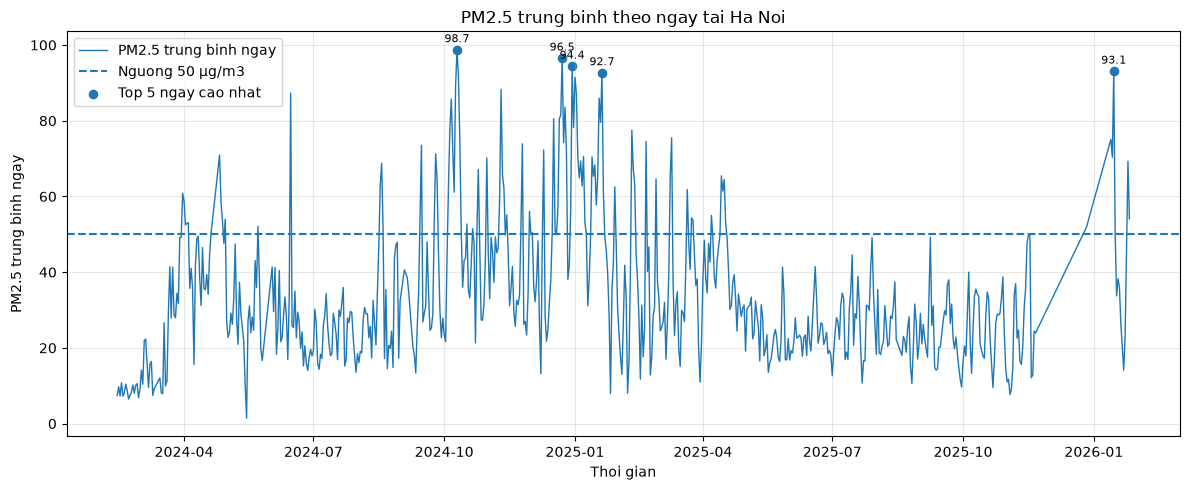

CAU 1: SO NGAY CO PM2.5 VUOT NGUONG
Khoang thoi gian phan tich: 2024-02-14 den 2026-01-26
Tong so ngay phan tich: 641 ngay
So ngay PM2.5 trung binh vuot nguong 50 µg/m3: 100 ngay
Ty le ngay vuot nguong: 15.60%
PM2.5 trung binh toan ky: 33.39 µg/m3
PM2.5 cao nhat theo ngay: 98.74 µg/m3
PM2.5 thap nhat theo ngay: 1.46 µg/m3

TOP 5 NGAY CO PM2.5 TRUNG BINH CAO NHAT:
- 2024-10-10: 98.74 µg/m3
- 2024-12-23: 96.52 µg/m3
- 2024-12-30: 94.38 µg/m3
- 2026-01-15: 93.07 µg/m3
- 2025-01-20: 92.65 µg/m3

NHAN XET:
- Trong tong so 641 ngay phan tich, co 100 ngay co PM2.5 trung binh vuot nguong 50 µg/m3, chiem 15.60%.
- Ket qua cho thay phan lon cac ngay co PM2.5 nam duoi nguong, tuy nhien van co mot so giai doan chat luong khong khi suy giam ro ret.

Da luu bang ket qua:
- output\bang_01_pm25_trung_binh_theo_ngay.csv

Da luu bieu do:
- output\bieu_do\bieu_do_01_pm25_trung_binh_theo_ngay.png


In [33]:
# ============================================================
# CAU 1:
# Tu ngay 14/02/2024 den ngay 26/01/2026,
# so ngay co PM2.5 vuot nguong la bao nhieu?
# ============================================================


NGUONG_PM25 = 50

# ============================================================
# 0. TAO THU MUC LUU KET QUA
# ============================================================

OUTPUT_DIR = "output"
CHART_DIR = os.path.join(OUTPUT_DIR, "bieu_do")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

# ============================================================
# 1. KIEM TRA DU LIEU
# ============================================================

if "df" not in globals():
    raise ValueError("Chua co bien df. Hay doc du lieu truoc bang pd.read_csv().")

if "pm25" not in df.columns:
    raise ValueError("Khong tim thay cot pm25 trong du lieu.")

# ============================================================
# 2. CHUAN HOA THOI GIAN
# ============================================================

if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df["ngay"] = df["datetime"].dt.date

elif "ngay_dt" in df.columns:
    df["ngay_dt"] = pd.to_datetime(df["ngay_dt"], errors="coerce")
    df["ngay"] = df["ngay_dt"].dt.date

else:
    raise ValueError("Khong tim thay cot datetime hoac ngay_dt trong du lieu.")

df["ngay"] = pd.to_datetime(df["ngay"])

# Xoa dong loi thoi gian
df = df.dropna(subset=["ngay"]).copy()

# Chuyen PM2.5 sang dang so
df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")

# Xoa dong khong co PM2.5
df = df.dropna(subset=["pm25"]).copy()

# ============================================================
# 3. TINH PM2.5 TRUNG BINH THEO NGAY
# ============================================================

pm25_theo_ngay = df.groupby("ngay").agg(
    pm25_trung_binh=("pm25", "mean")
).reset_index()

pm25_theo_ngay["ngay"] = pd.to_datetime(pm25_theo_ngay["ngay"])

# Xac dinh ngay vuot nguong
pm25_theo_ngay["vuot_nguong_50"] = (
    pm25_theo_ngay["pm25_trung_binh"] > NGUONG_PM25
)

# ============================================================
# 4. TINH CAC CHI SO KET QUA
# ============================================================

tong_so_ngay = len(pm25_theo_ngay)

so_ngay_vuot = pm25_theo_ngay["vuot_nguong_50"].sum()

ty_le_vuot = so_ngay_vuot / tong_so_ngay * 100

pm25_tb_toan_ky = pm25_theo_ngay["pm25_trung_binh"].mean()
pm25_max_toan_ky = pm25_theo_ngay["pm25_trung_binh"].max()
pm25_min_toan_ky = pm25_theo_ngay["pm25_trung_binh"].min()

# Neu cac cau sau can ten bien nay thi giu lai
so_ngay_vuot_nguong = so_ngay_vuot
ty_le_vuot_nguong = ty_le_vuot

# ============================================================
# 5. LUU BANG KET QUA
# ============================================================

duong_dan_bang = os.path.join(
    OUTPUT_DIR,
    "bang_01_pm25_trung_binh_theo_ngay.csv"
)

pm25_theo_ngay.to_csv(
    duong_dan_bang,
    index=False,
    encoding="utf-8-sig"
)

display(pm25_theo_ngay.head())

# ============================================================
# 6. LAY TOP 5 NGAY PM2.5 CAO NHAT
# ============================================================

top_5_ngay = pm25_theo_ngay.sort_values(
    by="pm25_trung_binh",
    ascending=False
).head(5)

display(top_5_ngay)

# ============================================================
# 7. VE BIEU DO PM2.5 TRUNG BINH THEO NGAY
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    pm25_theo_ngay["ngay"],
    pm25_theo_ngay["pm25_trung_binh"],
    linewidth=1,
    label="PM2.5 trung binh ngay"
)

plt.axhline(
    y=NGUONG_PM25,
    linestyle="--",
    linewidth=1.5,
    label=f"Nguong {NGUONG_PM25} µg/m3"
)

plt.scatter(
    top_5_ngay["ngay"],
    top_5_ngay["pm25_trung_binh"],
    s=35,
    label="Top 5 ngay cao nhat"
)

for _, row in top_5_ngay.iterrows():
    plt.text(
        row["ngay"],
        row["pm25_trung_binh"] + 2,
        f"{row['pm25_trung_binh']:.1f}",
        fontsize=8,
        ha="center"
    )

plt.title("PM2.5 trung binh theo ngay tai Ha Noi")
plt.xlabel("Thoi gian")
plt.ylabel("PM2.5 trung binh ngay")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

duong_dan_bieu_do = os.path.join(
    CHART_DIR,
    "bieu_do_01_pm25_trung_binh_theo_ngay.png"
)

plt.savefig(duong_dan_bieu_do, dpi=300)
plt.show()

# ============================================================
# 8. IN KET QUA VA NHAN XET
# ============================================================

print("=" * 90)
print("CAU 1: SO NGAY CO PM2.5 VUOT NGUONG")
print("=" * 90)

print(f"Khoang thoi gian phan tich: {pm25_theo_ngay['ngay'].min().date()} den {pm25_theo_ngay['ngay'].max().date()}")
print(f"Tong so ngay phan tich: {tong_so_ngay} ngay")
print(f"So ngay PM2.5 trung binh vuot nguong {NGUONG_PM25} µg/m3: {so_ngay_vuot} ngay")
print(f"Ty le ngay vuot nguong: {ty_le_vuot:.2f}%")
print(f"PM2.5 trung binh toan ky: {pm25_tb_toan_ky:.2f} µg/m3")
print(f"PM2.5 cao nhat theo ngay: {pm25_max_toan_ky:.2f} µg/m3")
print(f"PM2.5 thap nhat theo ngay: {pm25_min_toan_ky:.2f} µg/m3")

print("\nTOP 5 NGAY CO PM2.5 TRUNG BINH CAO NHAT:")
for i, row in top_5_ngay.iterrows():
    print(f"- {row['ngay'].date()}: {row['pm25_trung_binh']:.2f} µg/m3")

print("\nNHAN XET:")
print(
    f"- Trong tong so {tong_so_ngay} ngay phan tich, co {so_ngay_vuot} ngay "
    f"co PM2.5 trung binh vuot nguong {NGUONG_PM25} µg/m3, "
    f"chiem {ty_le_vuot:.2f}%."
)

print(
    "- Ket qua cho thay phan lon cac ngay co PM2.5 nam duoi nguong, "
    "tuy nhien van co mot so giai doan chat luong khong khi suy giam ro ret."
)

print("\nDa luu bang ket qua:")
print(f"- {duong_dan_bang}")

print("\nDa luu bieu do:")
print(f"- {duong_dan_bieu_do}")

In [20]:
# ============================================================
# CAU 2. Khung gio nao trong ngay thuong co PM2.5 cao nhat?
#PM2.5 trung bình của giờ đó = Tổng PM2.5 của tất cả bản ghi trong giờ đó / Số bản ghi trong giờ đó

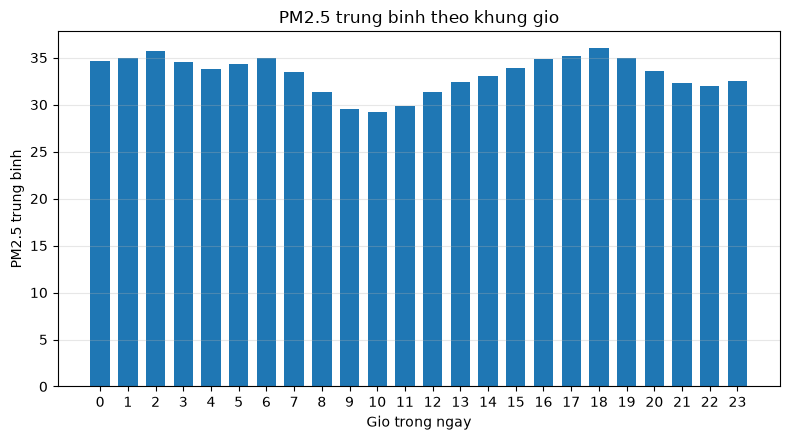

CAU 2: Khung gio co PM2.5 trung binh cao nhat la 18h, voi PM2.5 trung binh 36.00 µg/m3.


,gio,pm25_trung_binh,pm25_cao_nhat,pm25_thap_nhat,so_ban_ghi,xep_hang,ket_luan
0,18,36.004319,156.12,3.61000,606,1,Khung gio co PM2.5 trung binh cao nhat
1,2,35.716087,240.39,1.53000,604,2,
2,17,35.214545,143.02,4.29000,617,3,
3,1,34.971610,126.77,2.13000,605,4,
4,6,34.935573,119.14,0.45000,605,5,
5,19,34.930809,153.09,3.18000,607,6,
6,16,34.860574,122.56,3.66000,602,7,
7,0,34.643552,119.50,1.58000,605,8,
8,3,34.586737,174.74,0.00000,601,9,
9,5,34.318663,122.85,0.04000,606,10,


In [21]:
# ============================================================
# CAU 2: Khung gio nao trong ngay thuong co PM2.5 cao nhat?
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Dam bao kieu du lieu
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")

# Loc dung giai doan de tai
df_cau_02 = df[
    (df["datetime"] >= "2024-02-14") &
    (df["datetime"] <= "2026-01-26 23:59:59")
].copy()

# Tao cot gio
df_cau_02["gio"] = df_cau_02["datetime"].dt.hour

# Tinh PM2.5 theo tung khung gio
bang_02 = df_cau_02.groupby("gio").agg(
    pm25_trung_binh=("pm25", "mean"),
    pm25_cao_nhat=("pm25", "max"),
    pm25_thap_nhat=("pm25", "min"),
    so_ban_ghi=("pm25", "count")
).reset_index()

# Sap xep de tim gio cao nhat
bang_02_xep_hang = bang_02.sort_values(
    "pm25_trung_binh",
    ascending=False
).reset_index(drop=True)

bang_02_xep_hang["xep_hang"] = range(1, len(bang_02_xep_hang) + 1)

bang_02_xep_hang["ket_luan"] = np.where(
    bang_02_xep_hang["xep_hang"] == 1,
    "Khung gio co PM2.5 trung binh cao nhat",
    ""
)

# Luu bang output
bang_02_xep_hang.to_csv(
    os.path.join(OUTPUT_DIR, "bang_02_khung_gio_pm25_cao_nhat.csv"),
    index=False,
    encoding="utf-8-sig"
)

# Lay ket qua cao nhat
gio_cao_nhat = int(bang_02_xep_hang.iloc[0]["gio"])
pm25_gio_cao_nhat = bang_02_xep_hang.iloc[0]["pm25_trung_binh"]

# Sap xep theo gio de ve bieu do
bang_02_ve = bang_02.sort_values("gio").copy()

# ============================================================
# VE BIEU DO
# ============================================================

plt.figure(figsize=(8, 4.5))

plt.bar(
    bang_02_ve["gio"],
    bang_02_ve["pm25_trung_binh"],
    width=0.7
)

plt.xlabel("Gio trong ngay")
plt.ylabel("PM2.5 trung binh")
plt.title("PM2.5 trung binh theo khung gio")
plt.xticks(range(0, 24, 1))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "bieu_do_02_pm25_theo_gio.png"),
    dpi=300
)

plt.show()

# ============================================================
# IN KET QUA
# ============================================================

print(
    "CAU 2:",
    f"Khung gio co PM2.5 trung binh cao nhat la {gio_cao_nhat}h, "
    f"voi PM2.5 trung binh {pm25_gio_cao_nhat:.2f} µg/m3."
)

display(bang_02_xep_hang)

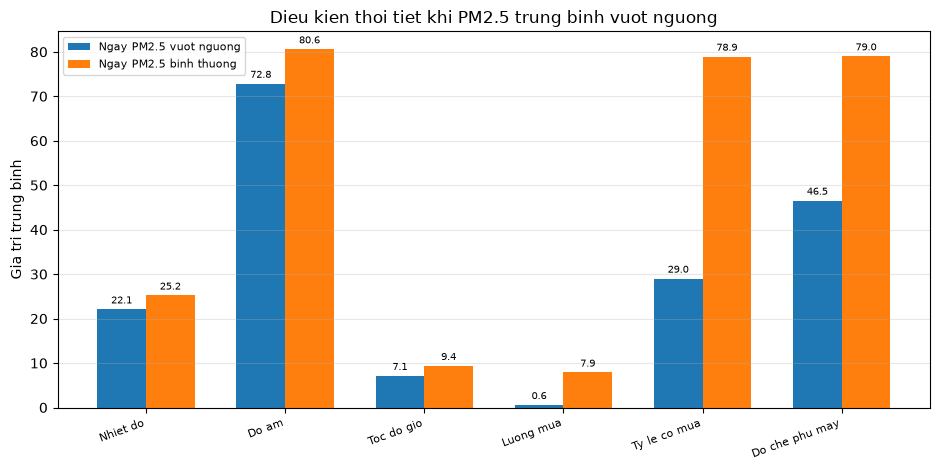

CAU 3: PM2.5 TRUNG BINH VUOT NGUONG THUONG XUAT HIEN TRONG DIEU KIEN THOI TIET NAO?
Co 100/641 ngay co PM2.5 trung binh vuot nguong 50 µg/m3, chiem 15.60%.

NHAN XET TU BIEU DO:
- Nhiet do trung binh cua ngay PM2.5 vuot nguong la 22.1, thap hon so voi ngay binh thuong la 25.2.
- Do am trung binh cua ngay PM2.5 vuot nguong la 72.8, thap hon so voi ngay binh thuong la 80.6.
- Toc do gio trung binh cua ngay PM2.5 vuot nguong la 7.1, thap hon so voi ngay binh thuong la 9.4.
- Luong mua trung binh cua ngay PM2.5 vuot nguong la 0.6, thap hon so voi ngay binh thuong la 7.9.
- Ty le ngay co mua khi PM2.5 vuot nguong la 29.0%, thap hon so voi ngay binh thuong la 78.9%.
- Do che phu may trung binh cua ngay PM2.5 vuot nguong la 46.5, thap hon so voi ngay binh thuong la 79.0.

Da luu bieu do:
- output/bieu_do/bieu_do_03_so_sanh_thoi_tiet_pm25_vuot_nguong.png


In [35]:
# ============================================================
# CAU 3:
# Chi so PM2.5 trung binh vuot nguong thuong xuat hien
# trong dieu kien thoi tiet nao?
#
# Su dung ket qua Cau 1:
# Ngay PM2.5 vuot nguong = pm25_trung_binh ngay > 50
# ============================================================



NGUONG_PM25 = 50

# ============================================================
# 1. CHUAN HOA DU LIEU THOI TIET
# ============================================================

if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df["ngay"] = df["datetime"].dt.date
elif "ngay_dt" in df.columns:
    df["ngay_dt"] = pd.to_datetime(df["ngay_dt"], errors="coerce")
    df["ngay"] = df["ngay_dt"].dt.date

df["ngay"] = pd.to_datetime(df["ngay"])

cot_thoi_tiet = [
    "temperature",
    "humidity",
    "wind_speed",
    "precipitation",
    "rain",
    "is_raining",
    "cloud_cover"
]

for col in cot_thoi_tiet:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "rain" not in df.columns:
    df["rain"] = 0

if "precipitation" not in df.columns:
    df["precipitation"] = 0

if "is_raining" not in df.columns:
    df["is_raining"] = np.where(
        (df["rain"] > 0) | (df["precipitation"] > 0),
        1,
        0
    )

# ============================================================
# 2. TINH DIEU KIEN THOI TIET THEO NGAY
# ============================================================

thoi_tiet_theo_ngay = df.groupby("ngay").agg(
    nhiet_do_trung_binh=("temperature", "mean"),
    do_am_trung_binh=("humidity", "mean"),
    toc_do_gio_trung_binh=("wind_speed", "mean"),
    luong_mua=("rain", "sum"),
    luong_mua_khac=("precipitation", "sum"),
    co_mua=("is_raining", "max"),
    do_che_phu_may_trung_binh=("cloud_cover", "mean")
).reset_index()

# ============================================================
# 3. GHEP KET QUA CAU 1 VOI DU LIEU THOI TIET
# ============================================================

pm25_theo_ngay["ngay"] = pd.to_datetime(pm25_theo_ngay["ngay"])

if "vuot_nguong_50" not in pm25_theo_ngay.columns:
    pm25_theo_ngay["vuot_nguong_50"] = pm25_theo_ngay["pm25_trung_binh"] > NGUONG_PM25

bang_cau_03 = pm25_theo_ngay.merge(
    thoi_tiet_theo_ngay,
    on="ngay",
    how="left"
)

df_vuot_nguong = bang_cau_03[bang_cau_03["vuot_nguong_50"]].copy()
df_binh_thuong = bang_cau_03[~bang_cau_03["vuot_nguong_50"]].copy()

so_ngay_vuot_nguong = len(df_vuot_nguong)
tong_so_ngay = len(bang_cau_03)
ty_le_vuot_nguong = so_ngay_vuot_nguong / tong_so_ngay * 100

# ============================================================
# 4. TINH GIA TRI TRUNG BINH CUA TUNG NHOM
# ============================================================

pm25_vuot = df_vuot_nguong["pm25_trung_binh"].mean()
pm25_bt = df_binh_thuong["pm25_trung_binh"].mean()

nhiet_do_vuot = df_vuot_nguong["nhiet_do_trung_binh"].mean()
nhiet_do_bt = df_binh_thuong["nhiet_do_trung_binh"].mean()

do_am_vuot = df_vuot_nguong["do_am_trung_binh"].mean()
do_am_bt = df_binh_thuong["do_am_trung_binh"].mean()

gio_vuot = df_vuot_nguong["toc_do_gio_trung_binh"].mean()
gio_bt = df_binh_thuong["toc_do_gio_trung_binh"].mean()

mua_vuot = df_vuot_nguong["luong_mua"].mean()
mua_bt = df_binh_thuong["luong_mua"].mean()

ty_le_mua_vuot = df_vuot_nguong["co_mua"].mean() * 100
ty_le_mua_bt = df_binh_thuong["co_mua"].mean() * 100

may_vuot = df_vuot_nguong["do_che_phu_may_trung_binh"].mean()
may_bt = df_binh_thuong["do_che_phu_may_trung_binh"].mean()

bang_ve = pd.DataFrame({
    "chi_tieu": [
        "Nhiet do",
        "Do am",
        "Toc do gio",
        "Luong mua",
        "Ty le co mua",
        "Do che phu may"
    ],
    "Ngay PM2.5 vuot nguong": [
        nhiet_do_vuot,
        do_am_vuot,
        gio_vuot,
        mua_vuot,
        ty_le_mua_vuot,
        may_vuot
    ],
    "Ngay PM2.5 binh thuong": [
        nhiet_do_bt,
        do_am_bt,
        gio_bt,
        mua_bt,
        ty_le_mua_bt,
        may_bt
    ]
})

bang_ve.to_csv(
    os.path.join(OUTPUT_DIR, "bang_03_so_sanh_thoi_tiet_pm25_vuot_nguong.csv"),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 5. VE BIEU DO SO SANH DIEU KIEN THOI TIET
# ============================================================

x = np.arange(len(bang_ve))
width = 0.35

plt.figure(figsize=(9.5, 4.8))

bar1 = plt.bar(
    x - width / 2,
    bang_ve["Ngay PM2.5 vuot nguong"],
    width,
    label="Ngay PM2.5 vuot nguong"
)

bar2 = plt.bar(
    x + width / 2,
    bang_ve["Ngay PM2.5 binh thuong"],
    width,
    label="Ngay PM2.5 binh thuong"
)

for bars in [bar1, bar2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{bar.get_height():.1f}",
            ha="center",
            va="bottom",
            fontsize=7
        )

plt.xticks(
    x,
    bang_ve["chi_tieu"],
    rotation=20,
    ha="right",
    fontsize=8
)

plt.ylabel("Gia tri trung binh")
plt.title("Dieu kien thoi tiet khi PM2.5 trung binh vuot nguong")
plt.grid(True, axis="y", alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "bieu_do_03_so_sanh_thoi_tiet_pm25_vuot_nguong.png"),
    dpi=300
)

plt.show()

# ============================================================
# 6. IN NHAN XET VA KET LUAN
# ============================================================

print("=" * 90)
print("CAU 3: PM2.5 TRUNG BINH VUOT NGUONG THUONG XUAT HIEN TRONG DIEU KIEN THOI TIET NAO?")
print("=" * 90)

print(
    f"Co {so_ngay_vuot_nguong}/{tong_so_ngay} ngay co PM2.5 trung binh "
    f"vuot nguong {NGUONG_PM25} µg/m3, chiem {ty_le_vuot_nguong:.2f}%."
)

print("\nNHAN XET TU BIEU DO:")

print(
    f"- Nhiet do trung binh cua ngay PM2.5 vuot nguong la {nhiet_do_vuot:.1f}, "
    f"thap hon so voi ngay binh thuong la {nhiet_do_bt:.1f}."
)

print(
    f"- Do am trung binh cua ngay PM2.5 vuot nguong la {do_am_vuot:.1f}, "
    f"thap hon so voi ngay binh thuong la {do_am_bt:.1f}."
)

print(
    f"- Toc do gio trung binh cua ngay PM2.5 vuot nguong la {gio_vuot:.1f}, "
    f"thap hon so voi ngay binh thuong la {gio_bt:.1f}."
)

print(
    f"- Luong mua trung binh cua ngay PM2.5 vuot nguong la {mua_vuot:.1f}, "
    f"thap hon so voi ngay binh thuong la {mua_bt:.1f}."
)

print(
    f"- Ty le ngay co mua khi PM2.5 vuot nguong la {ty_le_mua_vuot:.1f}%, "
    f"thap hon so voi ngay binh thuong la {ty_le_mua_bt:.1f}%."
)

print(
    f"- Do che phu may trung binh cua ngay PM2.5 vuot nguong la {may_vuot:.1f}, "
    f"thap hon so voi ngay binh thuong la {may_bt:.1f}."
)



print("\nDa luu bieu do:")
print("- output/bieu_do/bieu_do_03_so_sanh_thoi_tiet_pm25_vuot_nguong.png")

Các ngày PM2.5 vượt ngưỡng thường có nhiệt độ thấp hơn, độ ẩm thấp hơn, tốc độ gió yếu hơn và lượng mưa thấp hơn. Tỷ lệ ngày có mưa ở nhóm vượt ngưỡng thấp hơn rõ rệt so với nhóm ngày bình thường. Khi ít mưa và gió yếu, bụi mịn khó bị rửa trôi và khó phát tán, làm PM2.5 dễ tăng cao

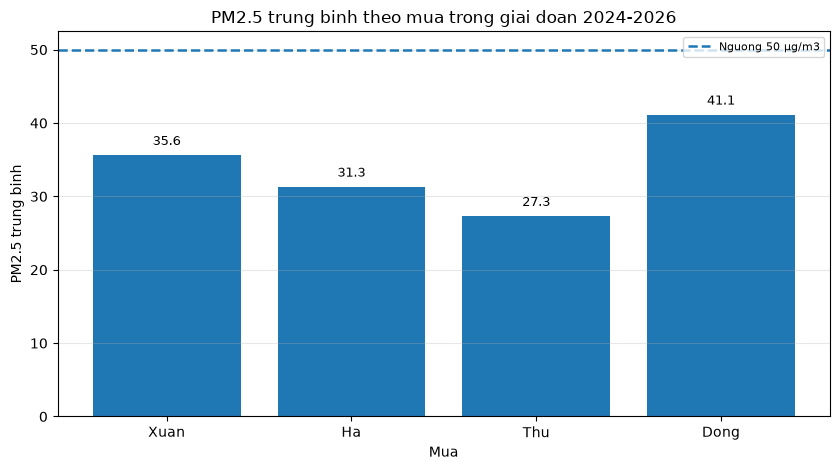

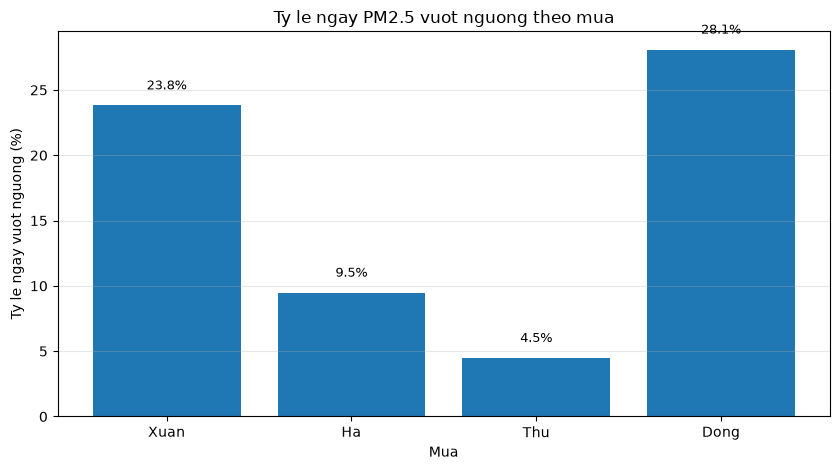

CAU 4: PM2.5 TAI HA NOI THAY DOI NHU THE NAO THEO MUA?

Bang PM2.5 theo mua:


,mua,pm25_trung_binh,pm25_cao_nhat,pm25_thap_nhat,so_ngay,so_ngay_vuot_nguong,ty_le_ngay_vuot_nguong,ket_luan
0,Xuan,35.592133,93.073000,6.489167,147,35,23.809524,
1,Ha,31.279996,87.306667,1.457143,169,16,9.467456,
2,Thu,27.285470,73.540417,9.669167,179,8,4.469274,Mua co PM2.5 trung binh thap nhat
3,Dong,41.107079,98.744167,7.670000,146,41,28.082192,Mua co PM2.5 trung binh cao nhat



Bang PM2.5 theo nam va theo mua:


,nam,mua,pm25_trung_binh,so_ngay,so_ngay_vuot_nguong,ty_le_ngay_vuot_nguong
0,2024,Xuan,17.906730,44,1,2.272727
1,2024,Ha,33.113437,80,11,13.750000
2,2024,Thu,29.862199,87,8,9.195402
3,2024,Dong,50.025220,92,38,41.304348
4,2025,Xuan,42.670282,90,28,31.111111
5,2025,Ha,29.631960,89,5,5.617978
6,2025,Thu,24.848780,92,0,0.000000
7,2025,Dong,25.913211,54,3,5.555556
8,2026,Xuan,46.447849,13,6,46.153846



NHAN XET:
- Mua Xuan: PM2.5 trung binh = 35.59 µg/m3, co 35/147 ngay vuot nguong, chiem 23.81%.
- Mua Ha: PM2.5 trung binh = 31.28 µg/m3, co 16/169 ngay vuot nguong, chiem 9.47%.
- Mua Thu: PM2.5 trung binh = 27.29 µg/m3, co 8/179 ngay vuot nguong, chiem 4.47%.
- Mua Dong: PM2.5 trung binh = 41.11 µg/m3, co 41/146 ngay vuot nguong, chiem 28.08%.

KET LUAN:
Trong giai doan 2024-2026, PM2.5 co su thay doi ro theo mua.

Mua co PM2.5 trung binh cao nhat la mua Dong, voi gia tri trung binh 41.11 µg/m3.

Mua co PM2.5 trung binh thap nhat la mua Thu, voi gia tri trung binh 27.29 µg/m3.

Dieu nay cho thay nong do PM2.5 tai Ha Noi khong phan bo dong deu quanh nam, ma co xu huong thay doi theo mua. Su khac biet nay co the lien quan den cac yeu to thoi tiet theo mua nhu nhiet do, do am, toc do gio va luong mua.

Da luu bang:
- output/bang_04_pm25_theo_mua.csv
- output/bang_04_pm25_theo_nam_va_mua.csv

Da luu bieu do:
- output/bieu_do/bieu_do_04_pm25_trung_binh_theo_mua.png
- output/bieu_do/bieu_

In [ ]:
# ============================================================
# CAU 4:
# Nong do PM2.5 tai Ha Noi thay doi nhu the nao theo mua
# trong giai doan 2024-2026?
#
# Quy uoc mua:
# Xuan: thang 1, 2, 3
# Ha:   thang 4, 5, 6
# Thu:  thang 7, 8, 9
# Dong: thang 10, 11, 12
# ============================================================

NGUONG_PM25 = 50

# ============================================================
# 1. CHUAN HOA DU LIEU
# ============================================================

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")

df_cau_04 = df[
    (df["datetime"] >= "2024-02-14") &
    (df["datetime"] <= "2026-01-26 23:59:59")
].copy()

df_cau_04["ngay"] = df_cau_04["datetime"].dt.date
df_cau_04["ngay"] = pd.to_datetime(df_cau_04["ngay"])
df_cau_04["nam"] = df_cau_04["datetime"].dt.year
df_cau_04["thang"] = df_cau_04["datetime"].dt.month

# ============================================================
# 2. GAN MUA THEO THANG
# ============================================================

def gan_mua(thang):
    if thang in [1, 2, 3]:
        return "Xuan"
    elif thang in [4, 5, 6]:
        return "Ha"
    elif thang in [7, 8, 9]:
        return "Thu"
    else:
        return "Dong"

df_cau_04["mua"] = df_cau_04["thang"].apply(gan_mua)

thu_tu_mua = ["Xuan", "Ha", "Thu", "Dong"]

# ============================================================
# 3. TINH PM2.5 TRUNG BINH THEO NGAY
# ============================================================

pm25_theo_ngay_mua = df_cau_04.groupby(["ngay", "nam", "mua"]).agg(
    pm25_trung_binh=("pm25", "mean"),
    pm25_cao_nhat=("pm25", "max"),
    pm25_thap_nhat=("pm25", "min"),
    so_ban_ghi=("pm25", "count")
).reset_index()

pm25_theo_ngay_mua["vuot_nguong_50"] = (
    pm25_theo_ngay_mua["pm25_trung_binh"] > NGUONG_PM25
)

# ============================================================
# 4. TINH PM2.5 THEO MUA
# ============================================================

bang_04 = pm25_theo_ngay_mua.groupby("mua").agg(
    pm25_trung_binh=("pm25_trung_binh", "mean"),
    pm25_cao_nhat=("pm25_trung_binh", "max"),
    pm25_thap_nhat=("pm25_trung_binh", "min"),
    so_ngay=("pm25_trung_binh", "count"),
    so_ngay_vuot_nguong=("vuot_nguong_50", "sum")
).reset_index()

bang_04["ty_le_ngay_vuot_nguong"] = (
    bang_04["so_ngay_vuot_nguong"] / bang_04["so_ngay"] * 100
)

bang_04["mua"] = pd.Categorical(
    bang_04["mua"],
    categories=thu_tu_mua,
    ordered=True
)

bang_04 = bang_04.sort_values("mua").reset_index(drop=True)

bang_04["ket_luan"] = np.where(
    bang_04["pm25_trung_binh"] == bang_04["pm25_trung_binh"].max(),
    "Mua co PM2.5 trung binh cao nhat",
    np.where(
        bang_04["pm25_trung_binh"] == bang_04["pm25_trung_binh"].min(),
        "Mua co PM2.5 trung binh thap nhat",
        ""
    )
)

bang_04.to_csv(
    os.path.join(OUTPUT_DIR, "bang_04_pm25_theo_mua.csv"),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 5. TINH PM2.5 THEO NAM VA THEO MUA
# ============================================================

bang_04_nam_mua = pm25_theo_ngay_mua.groupby(["nam", "mua"]).agg(
    pm25_trung_binh=("pm25_trung_binh", "mean"),
    so_ngay=("pm25_trung_binh", "count"),
    so_ngay_vuot_nguong=("vuot_nguong_50", "sum")
).reset_index()

bang_04_nam_mua["ty_le_ngay_vuot_nguong"] = (
    bang_04_nam_mua["so_ngay_vuot_nguong"] /
    bang_04_nam_mua["so_ngay"] * 100
)

bang_04_nam_mua["mua"] = pd.Categorical(
    bang_04_nam_mua["mua"],
    categories=thu_tu_mua,
    ordered=True
)

bang_04_nam_mua = bang_04_nam_mua.sort_values(
    ["nam", "mua"]
).reset_index(drop=True)

bang_04_nam_mua.to_csv(
    os.path.join(OUTPUT_DIR, "bang_04_pm25_theo_nam_va_mua.csv"),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 6. VE BIEU DO 1:
# PM2.5 TRUNG BINH THEO MUA
# ============================================================

plt.figure(figsize=(8.5, 4.8))

plt.bar(
    bang_04["mua"].astype(str),
    bang_04["pm25_trung_binh"]
)

plt.axhline(
    NGUONG_PM25,
    linestyle="--",
    linewidth=1.8,
    label="Nguong 50 µg/m3"
)

for index, row in bang_04.iterrows():
    plt.text(
        index,
        row["pm25_trung_binh"] + 1,
        f"{row['pm25_trung_binh']:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Mua")
plt.ylabel("PM2.5 trung binh")
plt.title("PM2.5 trung binh theo mua trong giai doan 2024-2026")
plt.grid(True, axis="y", alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "bieu_do_04_pm25_trung_binh_theo_mua.png"),
    dpi=300
)

plt.show()

# ============================================================
# 7. VE BIEU DO 2:
# TY LE NGAY VUOT NGUONG THEO MUA
# ============================================================

plt.figure(figsize=(8.5, 4.8))

plt.bar(
    bang_04["mua"].astype(str),
    bang_04["ty_le_ngay_vuot_nguong"]
)

for index, row in bang_04.iterrows():
    plt.text(
        index,
        row["ty_le_ngay_vuot_nguong"] + 1,
        f"{row['ty_le_ngay_vuot_nguong']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Mua")
plt.ylabel("Ty le ngay vuot nguong (%)")
plt.title("Ty le ngay PM2.5 vuot nguong theo mua")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "bieu_do_04_ty_le_ngay_vuot_nguong_theo_mua.png"),
    dpi=300
)

plt.show()

# ============================================================
# 8. IN KET QUA VA NHAN XET
# ============================================================

mua_cao_nhat = bang_04.loc[
    bang_04["pm25_trung_binh"].idxmax(),
    "mua"
]

pm25_mua_cao_nhat = bang_04["pm25_trung_binh"].max()

mua_thap_nhat = bang_04.loc[
    bang_04["pm25_trung_binh"].idxmin(),
    "mua"
]

pm25_mua_thap_nhat = bang_04["pm25_trung_binh"].min()

print("=" * 90)
print("CAU 4: PM2.5 TAI HA NOI THAY DOI NHU THE NAO THEO MUA?")
print("=" * 90)

print("\nBang PM2.5 theo mua:")
display(bang_04)

print("\nBang PM2.5 theo nam va theo mua:")
display(bang_04_nam_mua)

print("\nNHAN XET:")

for _, row in bang_04.iterrows():
    print(
        f"- Mua {row['mua']}: PM2.5 trung binh = {row['pm25_trung_binh']:.2f} µg/m3, "
        f"co {int(row['so_ngay_vuot_nguong'])}/{int(row['so_ngay'])} ngay vuot nguong, "
        f"chiem {row['ty_le_ngay_vuot_nguong']:.2f}%."
    )

print("\nKET LUAN:")
print(
    f"Trong giai doan 2024-2026, PM2.5 co su thay doi ro theo mua.\n\n"
    
    f"Mua co PM2.5 trung binh cao nhat la mua {mua_cao_nhat}, "
    f"voi gia tri trung binh {pm25_mua_cao_nhat:.2f} µg/m3.\n\n"
    
    f"Mua co PM2.5 trung binh thap nhat la mua {mua_thap_nhat}, "
    f"voi gia tri trung binh {pm25_mua_thap_nhat:.2f} µg/m3.\n\n"
    
    "Dieu nay cho thay nong do PM2.5 tai Ha Noi khong phan bo dong deu quanh nam, "
    "ma co xu huong thay doi theo mua. Su khac biet nay co the lien quan den "
    "cac yeu to thoi tiet theo mua nhu nhiet do, do am, toc do gio va luong mua."
)


In [25]:
# ============================================================
# CAU 5. Xu huong PM2.5 trong giai doan 2024-2026 dang tot len hay xau di?

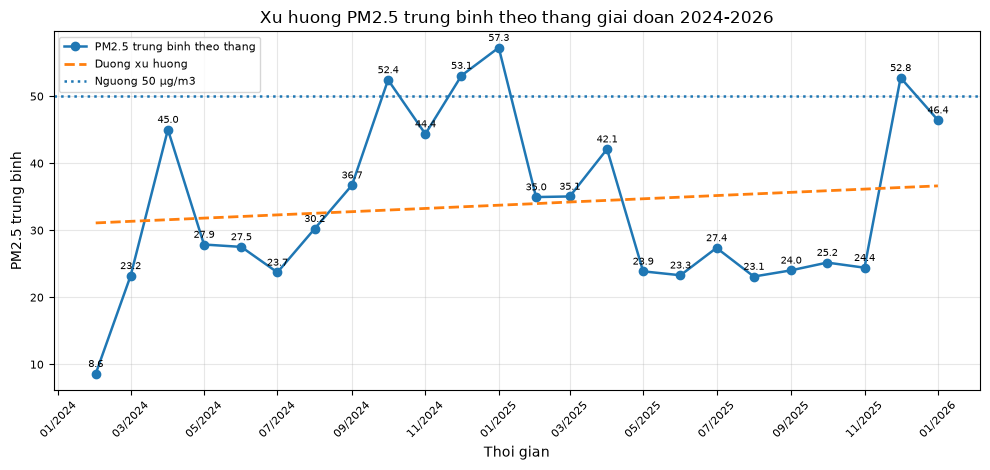

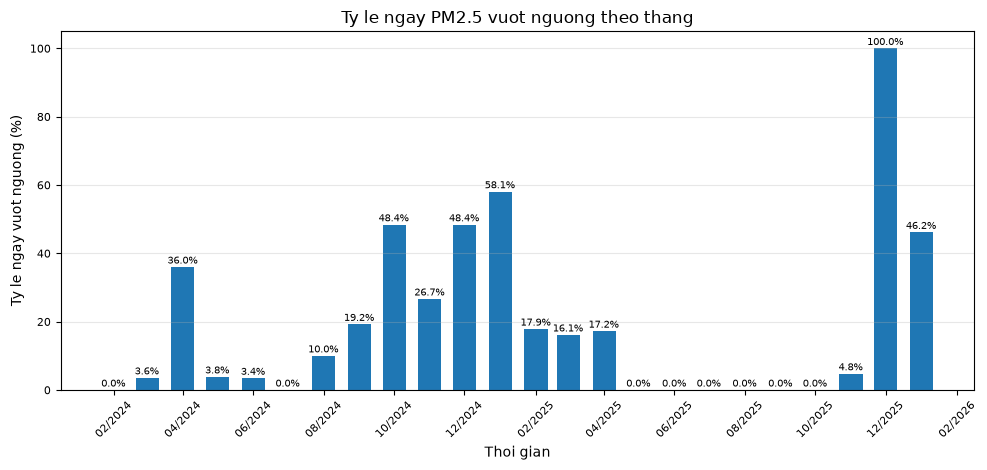

CAU 5: PM2.5 TRONG GIAI DOAN 2024-2026 DANG TOT LEN HAY XAU DI?
So thang phan tich: 24 thang
PM2.5 trung binh 3 thang dau ky: 25.62 µg/m3
PM2.5 trung binh 3 thang cuoi ky: 41.21 µg/m3
Chenh lech cuoi ky so voi dau ky: 15.59 µg/m3
Ty le thay doi: 60.85%
Do doc duong xu huong: 0.2403

KET LUAN:
Trong giai doan tu 2024-02-14 den 2026-01-26, xu huong PM2.5 duoc danh gia la: XAU DI.

Gia tri PM2.5 trung binh cua 3 thang dau ky la 25.62 µg/m3, trong khi 3 thang cuoi ky la 41.21 µg/m3.

Chenh lech giua cuoi ky va dau ky la 15.59 µg/m3, tuong ung voi muc thay doi 60.85%.

PM2.5 co xu huong tang theo thoi gian, chat luong khong khi co dau hieu xau di.

Da luu bang:
- output/bang_05_xu_huong_pm25_2024_2026.csv

Da luu bieu do:
- output/bieu_do/bieu_do_05_xu_huong_pm25_2024_2026.png
- output/bieu_do/bieu_do_05_ty_le_ngay_vuot_nguong_theo_thang.png


In [36]:
# ============================================================
# CAU 5:
# PM2.5 trong giai doan 2024-2026 dang tot len hay xau di?
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

NGUONG_PM25 = 50

# ============================================================
# 1. CHUAN HOA DU LIEU
# ============================================================

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")

df_cau_05 = df[
    (df["datetime"] >= "2024-02-14") &
    (df["datetime"] <= "2026-01-26 23:59:59")
].copy()

df_cau_05["ngay"] = df_cau_05["datetime"].dt.date
df_cau_05["ngay"] = pd.to_datetime(df_cau_05["ngay"])
df_cau_05["nam_thang"] = df_cau_05["datetime"].dt.to_period("M").dt.to_timestamp()

# ============================================================
# 2. TINH PM2.5 TRUNG BINH THEO NGAY
# ============================================================

pm25_theo_ngay_cau_05 = df_cau_05.groupby("ngay").agg(
    pm25_trung_binh=("pm25", "mean"),
    pm25_cao_nhat=("pm25", "max"),
    pm25_thap_nhat=("pm25", "min"),
    so_ban_ghi=("pm25", "count")
).reset_index()

pm25_theo_ngay_cau_05["vuot_nguong_50"] = (
    pm25_theo_ngay_cau_05["pm25_trung_binh"] > NGUONG_PM25
)

# ============================================================
# 3. TINH PM2.5 TRUNG BINH THEO THANG
# ============================================================

pm25_theo_ngay_cau_05["nam_thang"] = (
    pm25_theo_ngay_cau_05["ngay"].dt.to_period("M").dt.to_timestamp()
)

bang_05 = pm25_theo_ngay_cau_05.groupby("nam_thang").agg(
    pm25_trung_binh=("pm25_trung_binh", "mean"),
    pm25_cao_nhat=("pm25_trung_binh", "max"),
    pm25_thap_nhat=("pm25_trung_binh", "min"),
    so_ngay=("pm25_trung_binh", "count"),
    so_ngay_vuot_nguong=("vuot_nguong_50", "sum")
).reset_index()

bang_05["ty_le_ngay_vuot_nguong"] = (
    bang_05["so_ngay_vuot_nguong"] / bang_05["so_ngay"] * 100
)

# ============================================================
# 4. TINH DUONG XU HUONG
# ============================================================

# Tao bien thoi gian dang so: 0, 1, 2, ...
bang_05["thang_so"] = np.arange(len(bang_05))

# Duong xu huong tuyen tinh
he_so = np.polyfit(
    bang_05["thang_so"],
    bang_05["pm25_trung_binh"],
    1
)

do_doc = he_so[0]
he_so_chan = he_so[1]

bang_05["duong_xu_huong"] = (
    do_doc * bang_05["thang_so"] + he_so_chan
)

# ============================================================
# 5. SO SANH GIAI DOAN DAU VA CUOI
# ============================================================

so_thang_so_sanh = 3

pm25_dau_ky = bang_05.head(so_thang_so_sanh)["pm25_trung_binh"].mean()
pm25_cuoi_ky = bang_05.tail(so_thang_so_sanh)["pm25_trung_binh"].mean()

chenh_lech = pm25_cuoi_ky - pm25_dau_ky
ty_le_thay_doi = chenh_lech / pm25_dau_ky * 100

if do_doc < 0:
    xu_huong = "TOT LEN"
    ket_luan_xu_huong = "PM2.5 co xu huong giam theo thoi gian, chat luong khong khi co dau hieu tot len."
elif do_doc > 0:
    xu_huong = "XAU DI"
    ket_luan_xu_huong = "PM2.5 co xu huong tang theo thoi gian, chat luong khong khi co dau hieu xau di."
else:
    xu_huong = "ON DINH"
    ket_luan_xu_huong = "PM2.5 gan nhu khong thay doi ro ret theo thoi gian."

bang_05["xu_huong_chung"] = xu_huong

bang_05.to_csv(
    os.path.join(OUTPUT_DIR, "bang_05_xu_huong_pm25_2024_2026.csv"),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 6. VE BIEU DO XU HUONG PM2.5 THEO THANG
# ============================================================

plt.figure(figsize=(10, 4.8))

plt.plot(
    bang_05["nam_thang"],
    bang_05["pm25_trung_binh"],
    marker="o",
    linewidth=1.8,
    label="PM2.5 trung binh theo thang"
)

plt.plot(
    bang_05["nam_thang"],
    bang_05["duong_xu_huong"],
    linestyle="--",
    linewidth=2,
    label="Duong xu huong"
)

plt.axhline(
    NGUONG_PM25,
    linestyle=":",
    linewidth=1.8,
    label="Nguong 50 µg/m3"
)

for _, row in bang_05.iterrows():
    plt.text(
        row["nam_thang"],
        row["pm25_trung_binh"] + 1,
        f"{row['pm25_trung_binh']:.1f}",
        ha="center",
        fontsize=7
    )

plt.title("Xu huong PM2.5 trung binh theo thang giai doan 2024-2026")
plt.xlabel("Thoi gian")
plt.ylabel("PM2.5 trung binh")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "bieu_do_05_xu_huong_pm25_2024_2026.png"),
    dpi=300
)

plt.show()

# ============================================================
# 7. VE BIEU DO TY LE NGAY VUOT NGUONG THEO THANG
# ============================================================

plt.figure(figsize=(10, 4.8))

plt.bar(
    bang_05["nam_thang"],
    bang_05["ty_le_ngay_vuot_nguong"],
    width=20
)

for _, row in bang_05.iterrows():
    plt.text(
        row["nam_thang"],
        row["ty_le_ngay_vuot_nguong"] + 1,
        f"{row['ty_le_ngay_vuot_nguong']:.1f}%",
        ha="center",
        fontsize=7
    )

plt.title("Ty le ngay PM2.5 vuot nguong theo thang")
plt.xlabel("Thoi gian")
plt.ylabel("Ty le ngay vuot nguong (%)")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))

plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "bieu_do_05_ty_le_ngay_vuot_nguong_theo_thang.png"),
    dpi=300
)

plt.show()

# ============================================================
# 8. IN KET QUA VA KET LUAN
# ============================================================

print("=" * 90)
print("CAU 5: PM2.5 TRONG GIAI DOAN 2024-2026 DANG TOT LEN HAY XAU DI?")
print("=" * 90)

print(f"So thang phan tich: {len(bang_05)} thang")
print(f"PM2.5 trung binh 3 thang dau ky: {pm25_dau_ky:.2f} µg/m3")
print(f"PM2.5 trung binh 3 thang cuoi ky: {pm25_cuoi_ky:.2f} µg/m3")
print(f"Chenh lech cuoi ky so voi dau ky: {chenh_lech:.2f} µg/m3")
print(f"Ty le thay doi: {ty_le_thay_doi:.2f}%")
print(f"Do doc duong xu huong: {do_doc:.4f}")

print("\nKET LUAN:")
print(
    f"Trong giai doan tu 2024-02-14 den 2026-01-26, xu huong PM2.5 duoc danh gia la: {xu_huong}.\n\n"

    f"Gia tri PM2.5 trung binh cua 3 thang dau ky la {pm25_dau_ky:.2f} µg/m3, "
    f"trong khi 3 thang cuoi ky la {pm25_cuoi_ky:.2f} µg/m3.\n\n"

    f"Chenh lech giua cuoi ky va dau ky la {chenh_lech:.2f} µg/m3, "
    f"tuong ung voi muc thay doi {ty_le_thay_doi:.2f}%.\n\n"

    f"{ket_luan_xu_huong}"
)

print("\nDa luu bang:")
print("- output/bang_05_xu_huong_pm25_2024_2026.csv")

print("\nDa luu bieu do:")
print("- output/bieu_do/bieu_do_05_xu_huong_pm25_2024_2026.png")
print("- output/bieu_do/bieu_do_05_ty_le_ngay_vuot_nguong_theo_thang.png")

In [27]:
# ============================================================
# CAU 6. Du doan PM2.5 trung binh cua 06 thang dau nam 2026
# Mo hinh: Random Forest Regression

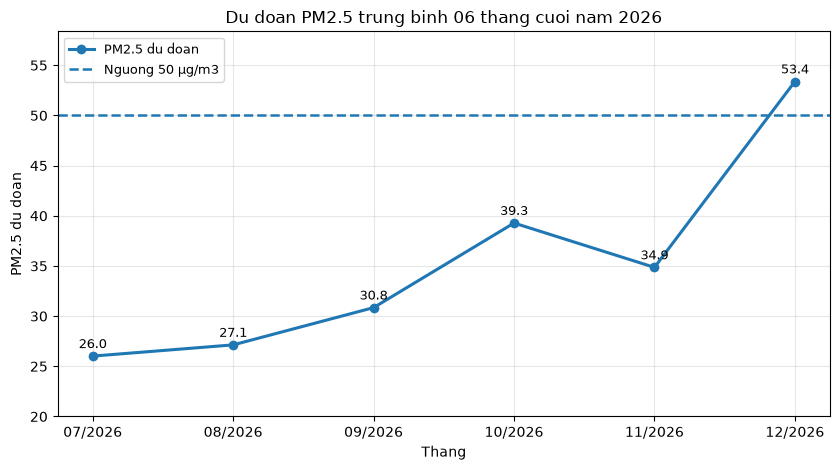

CAU 6: DU DOAN PM2.5 TRUNG BINH CUA 06 THANG CUOI NAM 2026

BANG DU DOAN RIENG PM2.5 TRUNG BINH 06 THANG CUOI NAM 2026:


,Thang,PM2.5 du doan,Nguong PM2.5,Danh gia
0,07/2026,26.02,50,Du bao khong vuot nguong
1,08/2026,27.14,50,Du bao khong vuot nguong
2,09/2026,30.85,50,Du bao khong vuot nguong
3,10/2026,39.28,50,Du bao khong vuot nguong
4,11/2026,34.86,50,Du bao khong vuot nguong
5,12/2026,53.38,50,Du bao vuot nguong



NHAN XET:
- Thang 07/2026: PM2.5 du doan = 26.02 µg/m3, du bao khong vuot nguong.
- Thang 08/2026: PM2.5 du doan = 27.14 µg/m3, du bao khong vuot nguong.
- Thang 09/2026: PM2.5 du doan = 30.85 µg/m3, du bao khong vuot nguong.
- Thang 10/2026: PM2.5 du doan = 39.28 µg/m3, du bao khong vuot nguong.
- Thang 11/2026: PM2.5 du doan = 34.86 µg/m3, du bao khong vuot nguong.
- Thang 12/2026: PM2.5 du doan = 53.38 µg/m3, du bao vuot nguong.

KET LUAN:
PM2.5 trung binh du doan trong 06 thang cuoi nam 2026 la 35.25 µg/m3.

Thang co PM2.5 du doan cao nhat la 12/2026, voi gia tri 53.38 µg/m3.

Thang co PM2.5 du doan thap nhat la 07/2026, voi gia tri 26.02 µg/m3.

Trong 06 thang cuoi nam 2026, co 1/6 thang du doan co PM2.5 trung binh vuot nguong 50 µg/m3.

Phuong phap du doan duoc thuc hien dua tren PM2.5 trung binh theo thang cua cac nam truoc, ket hop voi xu huong gan day. Cach lam nay giup ket qua du doan co the tang giam theo dac diem mua vu, thay vi chi tang deu hoac giam deu.

Da luu bang:
- 

In [28]:
# ============================================================
# CAU 6:
# Du doan PM2.5 trung binh 06 thang cuoi nam 2026
# Khong can statsmodels
# Cach lam: du doan theo trung binh cung thang cac nam truoc + xu huong gan day
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NGUONG_PM25 = 50

# ============================================================
# 1. CHUAN HOA DU LIEU
# ============================================================

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")

df_cau_06 = df[
    (df["datetime"] >= "2024-02-14") &
    (df["datetime"] <= "2026-01-26 23:59:59")
].copy()

df_cau_06["ngay"] = pd.to_datetime(df_cau_06["datetime"].dt.date)

# ============================================================
# 2. TINH PM2.5 TRUNG BINH THEO NGAY
# ============================================================

pm25_theo_ngay_cau_06 = df_cau_06.groupby("ngay").agg(
    pm25_trung_binh=("pm25", "mean")
).reset_index()

pm25_theo_ngay_cau_06["nam_thang"] = (
    pm25_theo_ngay_cau_06["ngay"].dt.to_period("M").dt.to_timestamp()
)

# ============================================================
# 3. TINH PM2.5 TRUNG BINH THEO THANG
# ============================================================

bang_thang = pm25_theo_ngay_cau_06.groupby("nam_thang").agg(
    pm25_trung_binh=("pm25_trung_binh", "mean")
).reset_index()

bang_thang = bang_thang.sort_values("nam_thang").reset_index(drop=True)

bang_thang["nam"] = bang_thang["nam_thang"].dt.year
bang_thang["thang"] = bang_thang["nam_thang"].dt.month
bang_thang["thang_so"] = np.arange(len(bang_thang))

# ============================================================
# 4. TINH XU HUONG GAN DAY
# Lay trung binh 6 thang gan nhat so voi 6 thang truoc do
# ============================================================

gan_nhat_6 = bang_thang.tail(6)["pm25_trung_binh"].mean()
truoc_do_6 = bang_thang.tail(12).head(6)["pm25_trung_binh"].mean()

muc_tang_giam_gan_day = gan_nhat_6 - truoc_do_6

# Giam nhe muc anh huong de du doan khong bi qua cao/thap
he_so_dieu_chinh = 0.3
dieu_chinh_xu_huong = muc_tang_giam_gan_day * he_so_dieu_chinh

# ============================================================
# 5. TAO DU LIEU 06 THANG CUOI NAM 2026
# ============================================================

thang_du_doan = pd.date_range(
    start="2026-07-01",
    end="2026-12-01",
    freq="MS"
)

bang_du_doan = pd.DataFrame({
    "nam_thang": thang_du_doan
})

bang_du_doan["thang"] = bang_du_doan["nam_thang"].dt.month
bang_du_doan["nam_thang_hien_thi"] = bang_du_doan["nam_thang"].dt.strftime("%m/%Y")

# ============================================================
# 6. DU DOAN THEO TRUNG BINH CUNG THANG CAC NAM TRUOC
# Vi du: du doan 07/2026 dua vao PM2.5 trung binh cac thang 7 truoc do
# ============================================================

du_doan_list = []

for _, row in bang_du_doan.iterrows():
    thang_can_du_doan = row["thang"]

    du_lieu_cung_thang = bang_thang[
        bang_thang["thang"] == thang_can_du_doan
    ]["pm25_trung_binh"]

    if len(du_lieu_cung_thang) > 0:
        gia_tri_mua_vu = du_lieu_cung_thang.mean()
    else:
        gia_tri_mua_vu = bang_thang["pm25_trung_binh"].mean()

    pm25_du_doan = gia_tri_mua_vu + dieu_chinh_xu_huong

    du_doan_list.append(pm25_du_doan)

bang_du_doan["pm25_du_doan"] = du_doan_list
bang_du_doan["nguong_pm25"] = NGUONG_PM25

bang_du_doan["danh_gia"] = np.where(
    bang_du_doan["pm25_du_doan"] > NGUONG_PM25,
    "Du bao vuot nguong",
    "Du bao khong vuot nguong"
)

# ============================================================
# 7. TAO BANG DU DOAN RIENG
# ============================================================

bang_du_doan_rieng = bang_du_doan[
    [
        "nam_thang_hien_thi",
        "pm25_du_doan",
        "nguong_pm25",
        "danh_gia"
    ]
].copy()

bang_du_doan_rieng = bang_du_doan_rieng.rename(columns={
    "nam_thang_hien_thi": "Thang",
    "pm25_du_doan": "PM2.5 du doan",
    "nguong_pm25": "Nguong PM2.5",
    "danh_gia": "Danh gia"
})

bang_du_doan_rieng["PM2.5 du doan"] = bang_du_doan_rieng["PM2.5 du doan"].round(2)

bang_du_doan_rieng.to_csv(
    os.path.join(OUTPUT_DIR, "bang_06_du_doan_pm25_06_thang_cuoi_2026.csv"),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 8. VE BIEU DO DU DOAN RIENG
# ============================================================

plt.figure(figsize=(8.5, 4.8))

plt.plot(
    bang_du_doan["nam_thang_hien_thi"],
    bang_du_doan["pm25_du_doan"],
    marker="o",
    linewidth=2.2,
    label="PM2.5 du doan"
)

plt.axhline(
    NGUONG_PM25,
    linestyle="--",
    linewidth=1.8,
    label="Nguong 50 µg/m3"
)

for _, row in bang_du_doan.iterrows():
    plt.text(
        row["nam_thang_hien_thi"],
        row["pm25_du_doan"] + 0.5,
        f"{row['pm25_du_doan']:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Du doan PM2.5 trung binh 06 thang cuoi nam 2026")
plt.xlabel("Thang")
plt.ylabel("PM2.5 du doan")

plt.ylim(
    min(bang_du_doan["pm25_du_doan"].min() - 5, 20),
    max(bang_du_doan["pm25_du_doan"].max() + 5, NGUONG_PM25 + 5)
)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "bieu_do_06_du_doan_pm25_06_thang_cuoi_2026.png"),
    dpi=300
)

plt.show()

# ============================================================
# 9. IN KET QUA
# ============================================================

so_thang_vuot = (bang_du_doan["pm25_du_doan"] > NGUONG_PM25).sum()
pm25_tb_6_thang = bang_du_doan["pm25_du_doan"].mean()
pm25_cao_nhat = bang_du_doan["pm25_du_doan"].max()
pm25_thap_nhat = bang_du_doan["pm25_du_doan"].min()

thang_cao_nhat = bang_du_doan.loc[
    bang_du_doan["pm25_du_doan"].idxmax(),
    "nam_thang_hien_thi"
]

thang_thap_nhat = bang_du_doan.loc[
    bang_du_doan["pm25_du_doan"].idxmin(),
    "nam_thang_hien_thi"
]

print("=" * 90)
print("CAU 6: DU DOAN PM2.5 TRUNG BINH CUA 06 THANG CUOI NAM 2026")
print("=" * 90)

print("\nBANG DU DOAN RIENG PM2.5 TRUNG BINH 06 THANG CUOI NAM 2026:")
display(bang_du_doan_rieng)

print("\nNHAN XET:")

for _, row in bang_du_doan.iterrows():
    print(
        f"- Thang {row['nam_thang_hien_thi']}: PM2.5 du doan = "
        f"{row['pm25_du_doan']:.2f} µg/m3, {row['danh_gia'].lower()}."
    )

print("\nKET LUAN:")
print(
    f"PM2.5 trung binh du doan trong 06 thang cuoi nam 2026 la "
    f"{pm25_tb_6_thang:.2f} µg/m3.\n\n"

    f"Thang co PM2.5 du doan cao nhat la {thang_cao_nhat}, "
    f"voi gia tri {pm25_cao_nhat:.2f} µg/m3.\n\n"

    f"Thang co PM2.5 du doan thap nhat la {thang_thap_nhat}, "
    f"voi gia tri {pm25_thap_nhat:.2f} µg/m3.\n\n"

    f"Trong 06 thang cuoi nam 2026, co {so_thang_vuot}/6 thang du doan "
    f"co PM2.5 trung binh vuot nguong {NGUONG_PM25} µg/m3.\n\n"

    "Phuong phap du doan duoc thuc hien dua tren PM2.5 trung binh theo thang "
    "cua cac nam truoc, ket hop voi xu huong gan day. Cach lam nay giup ket qua "
    "du doan co the tang giam theo dac diem mua vu, thay vi chi tang deu hoac giam deu."
)

print("\nDa luu bang:")
print("- output/bang_06_du_doan_pm25_06_thang_cuoi_2026.csv")

print("\nDa luu bieu do:")
print("- output/bieu_do/bieu_do_06_du_doan_pm25_06_thang_cuoi_2026.png")

In [29]:
# ============================================================
# CAU 7. Phan cum PM2.5 bang KMeans thanh 03 nhom: thap, trung binh, cao

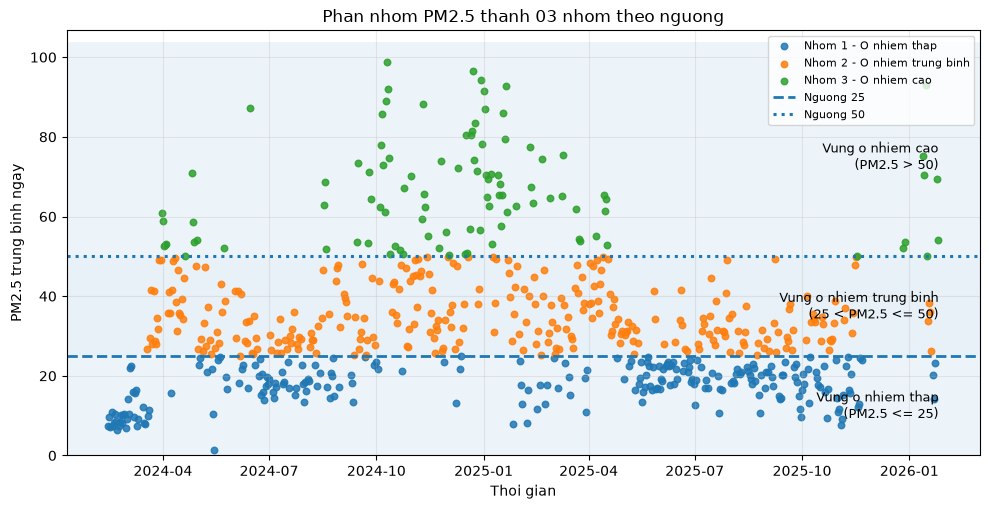

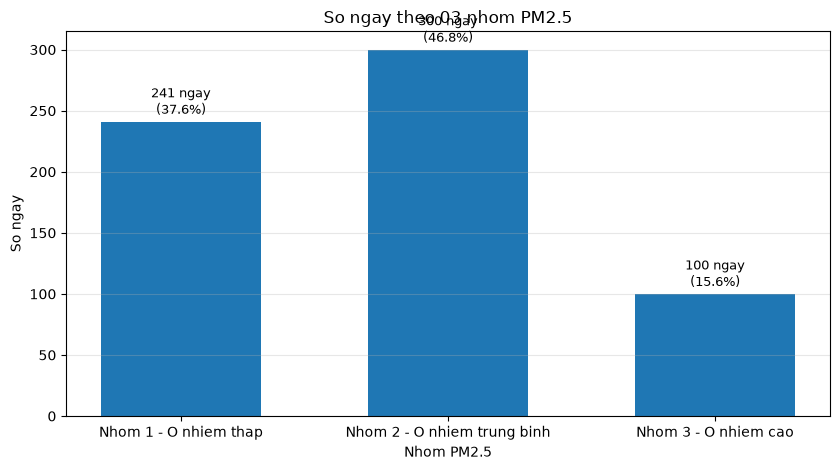

CAU 7: PHAN NHOM PM2.5 THANH 03 NHOM

Bang tong hop phan nhom PM2.5:


,nhom_pm25,dieu_kien_pm25,so_ngay,pm25_trung_binh,pm25_thap_nhat,pm25_cao_nhat,ty_le
0,Nhom 1 - O nhiem thap,PM2.5 <= 25,241,17.633564,1.457143,24.945417,37.597504
1,Nhom 2 - O nhiem trung binh,25 < PM2.5 <= 50,300,34.992643,25.078333,49.952083,46.801872
2,Nhom 3 - O nhiem cao,PM2.5 > 50,100,66.566139,50.120556,98.744167,15.600624



NHAN XET:
- Nhom 1 - O nhiem thap: 241 ngay, chiem 37.60%, dieu kien PM2.5 <= 25.
- Nhom 2 - O nhiem trung binh: 300 ngay, chiem 46.80%, dieu kien 25 < PM2.5 <= 50.
- Nhom 3 - O nhiem cao: 100 ngay, chiem 15.60%, dieu kien PM2.5 > 50.

KET LUAN:
Cac ngay duoc chia thanh 03 nhom dua tren PM2.5 trung binh ngay.

Nhom 1 la o nhiem thap voi dieu kien PM2.5 <= 25.
Nhom 2 la o nhiem trung binh voi dieu kien 25 < PM2.5 <= 50.
Nhom 3 la o nhiem cao voi dieu kien PM2.5 > 50.

Cach chia nay giup cac nhom tach biet ro rang, dung theo nguong de bai yeu cau, nen de giai thich va de thuyet trinh hon.

Da luu bang:
- output/bang_07_chi_tiet_phan_nhom_pm25.csv
- output/bang_07_tong_hop_phan_nhom_pm25.csv

Da luu bieu do:
- output/bieu_do/bieu_do_07_phan_nhom_pm25_theo_nguong.png
- output/bieu_do/bieu_do_07_so_ngay_theo_nhom_pm25.png


In [30]:
# ============================================================
# CAU 7:
# PHAN NHOM PM2.5 THANH 03 NHOM THEO NGUONG
# Nhom 1: PM2.5 <= 25
# Nhom 2: 25 < PM2.5 <= 50
# Nhom 3: PM2.5 > 50
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NGUONG_THAP = 25
NGUONG_CAO = 50

# ============================================================
# 1. CHUAN HOA DU LIEU
# ============================================================

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")

df_cau_07 = df[
    (df["datetime"] >= "2024-02-14") &
    (df["datetime"] <= "2026-01-26 23:59:59")
].copy()

df_cau_07["ngay"] = pd.to_datetime(df_cau_07["datetime"].dt.date)

# ============================================================
# 2. TINH PM2.5 TRUNG BINH THEO NGAY
# ============================================================

pm25_theo_ngay_cau_07 = df_cau_07.groupby("ngay").agg(
    pm25_trung_binh=("pm25", "mean"),
    pm25_cao_nhat=("pm25", "max"),
    pm25_thap_nhat=("pm25", "min"),
    so_ban_ghi=("pm25", "count")
).reset_index()

pm25_theo_ngay_cau_07 = pm25_theo_ngay_cau_07.dropna(subset=["pm25_trung_binh"])

# ============================================================
# 3. PHAN NHOM THEO NGUONG CO DINH
# ============================================================

def phan_nhom_pm25(pm25):
    if pm25 <= NGUONG_THAP:
        return "Nhom 1 - O nhiem thap"
    elif pm25 <= NGUONG_CAO:
        return "Nhom 2 - O nhiem trung binh"
    else:
        return "Nhom 3 - O nhiem cao"

def dieu_kien_pm25(pm25):
    if pm25 <= NGUONG_THAP:
        return "PM2.5 <= 25"
    elif pm25 <= NGUONG_CAO:
        return "25 < PM2.5 <= 50"
    else:
        return "PM2.5 > 50"

pm25_theo_ngay_cau_07["nhom_pm25"] = pm25_theo_ngay_cau_07["pm25_trung_binh"].apply(phan_nhom_pm25)
pm25_theo_ngay_cau_07["dieu_kien_pm25"] = pm25_theo_ngay_cau_07["pm25_trung_binh"].apply(dieu_kien_pm25)

# ============================================================
# 4. BANG TONG HOP
# ============================================================

bang_07 = pm25_theo_ngay_cau_07.groupby(
    ["nhom_pm25", "dieu_kien_pm25"]
).agg(
    so_ngay=("pm25_trung_binh", "count"),
    pm25_trung_binh=("pm25_trung_binh", "mean"),
    pm25_thap_nhat=("pm25_trung_binh", "min"),
    pm25_cao_nhat=("pm25_trung_binh", "max")
).reset_index()

bang_07["ty_le"] = bang_07["so_ngay"] / bang_07["so_ngay"].sum() * 100

thu_tu_nhom = {
    "Nhom 1 - O nhiem thap": 1,
    "Nhom 2 - O nhiem trung binh": 2,
    "Nhom 3 - O nhiem cao": 3
}

bang_07["thu_tu"] = bang_07["nhom_pm25"].map(thu_tu_nhom)
bang_07 = bang_07.sort_values("thu_tu").drop(columns=["thu_tu"])

# ============================================================
# 5. LUU FILE
# ============================================================

pm25_theo_ngay_cau_07.to_csv(
    os.path.join(OUTPUT_DIR, "bang_07_chi_tiet_phan_nhom_pm25.csv"),
    index=False,
    encoding="utf-8-sig"
)

bang_07.to_csv(
    os.path.join(OUTPUT_DIR, "bang_07_tong_hop_phan_nhom_pm25.csv"),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 6. BIEU DO 1: PHAN NHOM THEO NGUONG - RO RANG
# ============================================================

plt.figure(figsize=(10, 5.2))

# Nen 3 vung
plt.axhspan(0, 25, alpha=0.08)
plt.axhspan(25, 50, alpha=0.10)
plt.axhspan(50, pm25_theo_ngay_cau_07["pm25_trung_binh"].max() + 5, alpha=0.08)

# Ve tung nhom dung theo nguong
for nhom in [
    "Nhom 1 - O nhiem thap",
    "Nhom 2 - O nhiem trung binh",
    "Nhom 3 - O nhiem cao"
]:
    du_lieu_nhom = pm25_theo_ngay_cau_07[
        pm25_theo_ngay_cau_07["nhom_pm25"] == nhom
    ]

    plt.scatter(
        du_lieu_nhom["ngay"],
        du_lieu_nhom["pm25_trung_binh"],
        s=22,
        alpha=0.85,
        label=nhom
    )

# Ve 2 nguong
plt.axhline(NGUONG_THAP, linestyle="--", linewidth=2, label="Nguong 25")
plt.axhline(NGUONG_CAO, linestyle=":", linewidth=2.2, label="Nguong 50")

# Ghi chu 3 vung
x_text = pm25_theo_ngay_cau_07["ngay"].max()

plt.text(
    x_text, 12.5,
    "Vung o nhiem thap\n(PM2.5 <= 25)",
    ha="right", va="center", fontsize=9
)

plt.text(
    x_text, 37.5,
    "Vung o nhiem trung binh\n(25 < PM2.5 <= 50)",
    ha="right", va="center", fontsize=9
)

plt.text(
    x_text, 75,
    "Vung o nhiem cao\n(PM2.5 > 50)",
    ha="right", va="center", fontsize=9
)

plt.xlabel("Thoi gian")
plt.ylabel("PM2.5 trung binh ngay")
plt.title("Phan nhom PM2.5 thanh 03 nhom theo nguong")
plt.ylim(0, pm25_theo_ngay_cau_07["pm25_trung_binh"].max() + 8)
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8, loc="upper right")
plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "bieu_do_07_phan_nhom_pm25_theo_nguong.png"),
    dpi=300
)

plt.show()

# ============================================================
# 7. BIEU DO 2: SO NGAY THEO NHOM
# ============================================================

plt.figure(figsize=(8.5, 4.8))

plt.bar(
    bang_07["nhom_pm25"],
    bang_07["so_ngay"],
    width=0.6
)

for index, row in bang_07.iterrows():
    plt.text(
        index,
        row["so_ngay"] + 3,
        f"{int(row['so_ngay'])} ngay\n({row['ty_le']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Nhom PM2.5")
plt.ylabel("So ngay")
plt.title("So ngay theo 03 nhom PM2.5")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "bieu_do_07_so_ngay_theo_nhom_pm25.png"),
    dpi=300
)

plt.show()

# ============================================================
# 8. IN KET QUA
# ============================================================

print("=" * 90)
print("CAU 7: PHAN NHOM PM2.5 THANH 03 NHOM")
print("=" * 90)

print("\nBang tong hop phan nhom PM2.5:")
display(bang_07)

print("\nNHAN XET:")
for _, row in bang_07.iterrows():
    print(
        f"- {row['nhom_pm25']}: {int(row['so_ngay'])} ngay, "
        f"chiem {row['ty_le']:.2f}%, dieu kien {row['dieu_kien_pm25']}."
    )

print("\nKET LUAN:")
print(
    "Cac ngay duoc chia thanh 03 nhom dua tren PM2.5 trung binh ngay.\n\n"
    "Nhom 1 la o nhiem thap voi dieu kien PM2.5 <= 25.\n"
    "Nhom 2 la o nhiem trung binh voi dieu kien 25 < PM2.5 <= 50.\n"
    "Nhom 3 la o nhiem cao voi dieu kien PM2.5 > 50.\n\n"
    "Cach chia nay giup cac nhom tach biet ro rang, dung theo nguong de bai yeu cau, "
    "nen de giai thich va de thuyet trinh hon."
)

print("\nDa luu bang:")
print("- output/bang_07_chi_tiet_phan_nhom_pm25.csv")
print("- output/bang_07_tong_hop_phan_nhom_pm25.csv")

print("\nDa luu bieu do:")
print("- output/bieu_do/bieu_do_07_phan_nhom_pm25_theo_nguong.png")
print("- output/bieu_do/bieu_do_07_so_ngay_theo_nhom_pm25.png")